# LAB 6 Recurrent Neural Networks
## D7041E	“Applied	artificial	intelligence”

Magnus H

# Results




Mackey glass
* RMSE for first 500 steps = 0.062


Sinusoidal
* RMSE for first 500 steps = 1.78e-07





LEAF dataset:

* Run 1: Accuracy = 0.8192
* Run 2: Accuracy = 0.8416
* Run 3: Accuracy = 0.84
* Run 4: Accuracy = 0.8448
* Run 5: Accuracy = 0.8464
* Run 6: Accuracy = 0.8496
* Run 7: Accuracy = 0.8432
* Run 8: Accuracy = 0.8432
* Run 9: Accuracy = 0.816
* Run 10: Accuracy = 0.8272

Average accuracy: 0.83712

## QnA:
* What does teacher forcing mean?

From of training sequence, common for RNN's where we actually use the ground truth during training as input parameters.

* Whats ridge regression?  

A linear regression function that uses L2 penalty to the loss function.

* How to achieve the echo state property?  

ESP ensures that the state reservoir is more infuensed by recent inputs rather than older ones.

* What's Root mean square?

Its a form of measurement of predicting accuracy by penalizing large error more than small ones.


In [ ]:


import numpy as np
import matplotlib.pyplot as plt

# check for intuition at http://users.fs.cvut.cz/ivo.bukovsky/PVVR/prace_studentu/Mackey_Glass_time_series_prediction_Fuzzy_Lookup.pdf

def mackey_glass(tau, length):
    betta=0.2
    gamma = 0.1
    a=10
    delay=100 # will cut these initial steps

    y=np.random.rand(tau) # random intial values between 0 and 1
    # Euler's method to solve the differential equation
    for t in range(tau-1, length+delay+tau-1):
        current= y[t] + ( betta * y[t-(tau-1)]   / ( 1 + np.power(y[t-(tau-1)], a)   )  ) - gamma*y[t]
        y=np.append(y, current)

    y=y-1 # get rid of mean
    y=np.tanh(y) # squeze with tanh

    return y[tau+delay:length+delay+tau]


RMSE for first 500 steps = 0.08998664826385158


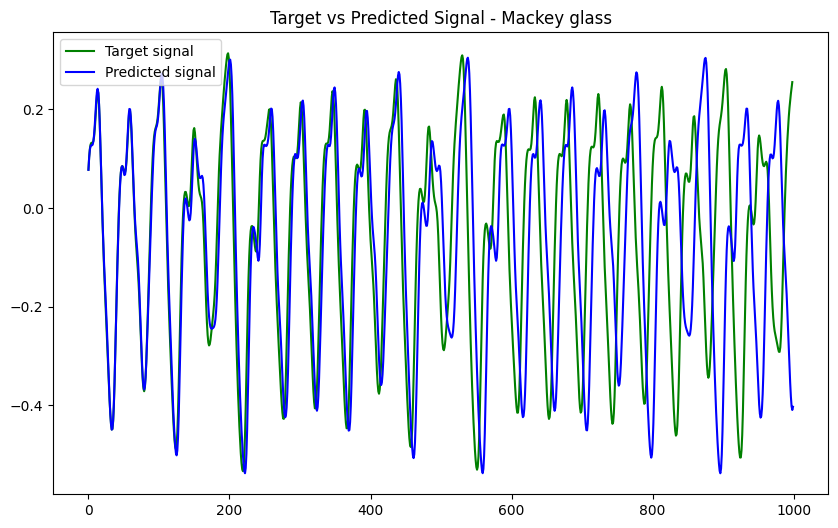

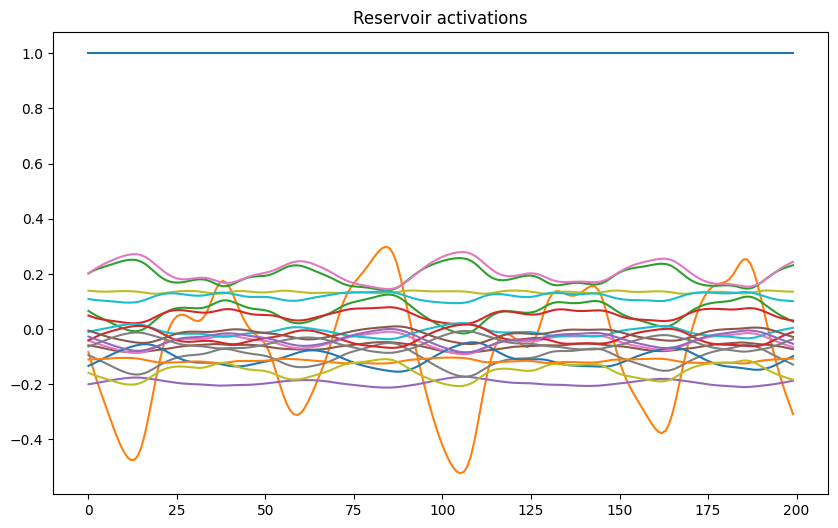

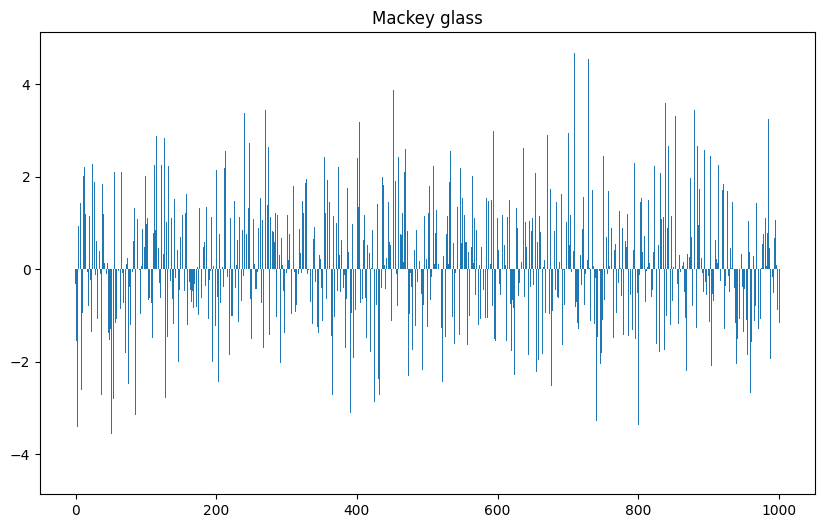

In [ ]:
# Ref Practical Guide to Applying ESN
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

# Parameters
train_len = 3000
test_len = 1000
init_len = 1000
reservoir_size = 1000
spectral_radius = 0.8
reg = 1e-8

# Generate dataset
data = mackey_glass(tau=17, length=train_len + test_len)

# Generate ESN reservoir
np.random.seed(42)
Win = (np.random.rand(reservoir_size, 1 + 1) - 0.5) * 0.2  # Scale as per lab instructions
W = np.random.rand(reservoir_size, reservoir_size) - 0.5
rhoW = max(abs(np.linalg.eigvals(W)))
W *= spectral_radius / rhoW

# Allocate memory for the design matrix
X = np.zeros((1 + 1 + reservoir_size, train_len - init_len))
Yt = data[None, init_len + 1 : train_len + 1]  # Target matrix

# Run the reservoir and collect states
x = np.zeros((reservoir_size, 1))
for t in range(train_len):
    u = data[t]
    x = np.tanh(np.dot(Win, np.vstack((1, u))) + np.dot(W, x))  # α=1 as per lab
    if t >= init_len:
        X[:, t - init_len] = np.vstack((1, u, x))[:, 0]

# Train ESN using ridge regression
Wout = solve(np.dot(X, X.T) + reg * np.eye(1 + 1 + reservoir_size), np.dot(X, Yt.T)).T

# Test ESN in generative mode
Y = np.zeros((1, test_len))
u = data[train_len]
for t in range(test_len):
    x = np.tanh(np.dot(Win, np.vstack((1, u))) + np.dot(W, x))
    y = np.dot(Wout, np.vstack((1, u, x)))
    Y[:, t] = y
    u = y

# RMSE for 500 steps
error_len = 500
mse = np.mean((data[train_len + 1 : train_len + error_len + 1] - Y[0, :error_len]) ** 2)
rmse = np.sqrt(mse)
print(f"RMSE for first 500 steps = {rmse}")

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(data[train_len + 1 : train_len + test_len + 1], 'g', label="Target signal")
plt.plot(Y.T, 'b', label="Predicted signal")
plt.title("Target vs Predicted Signal - Mackey glass")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(X[0:20, 0:200].T)
plt.title("Reservoir activations")
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(np.arange(1 + 1 + reservoir_size), Wout[0].T)
plt.title("Mackey glass")
plt.show()


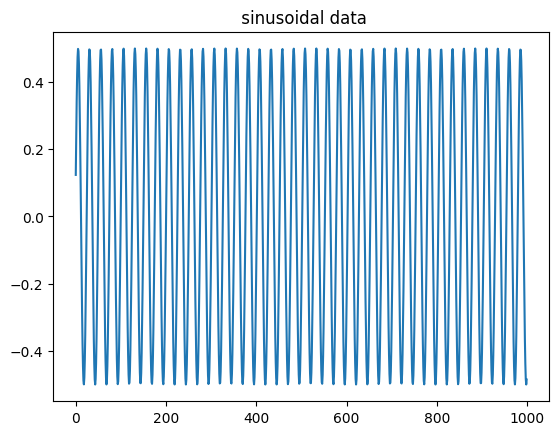

RMSE for first 500 steps = 1.7897557045344345e-07


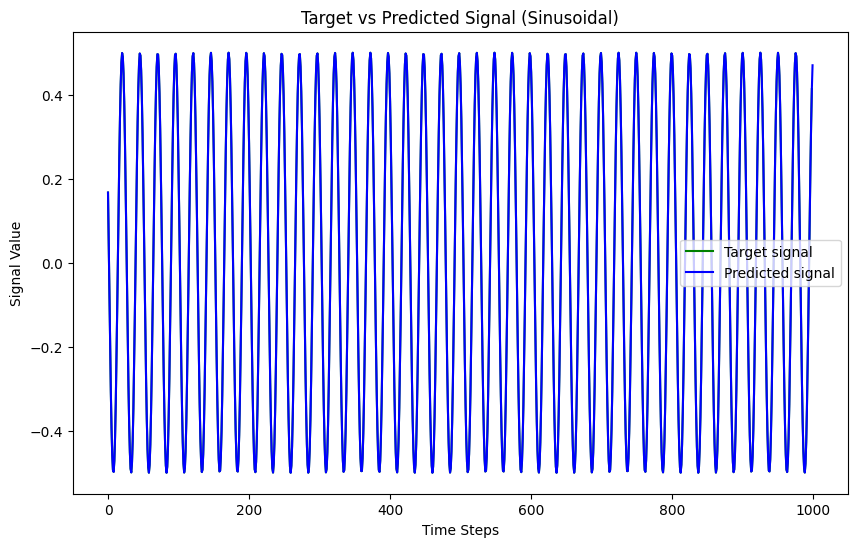

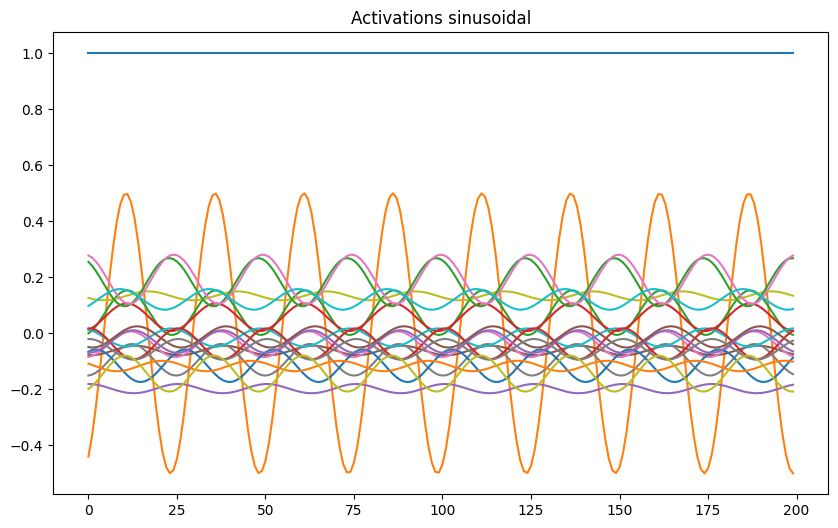

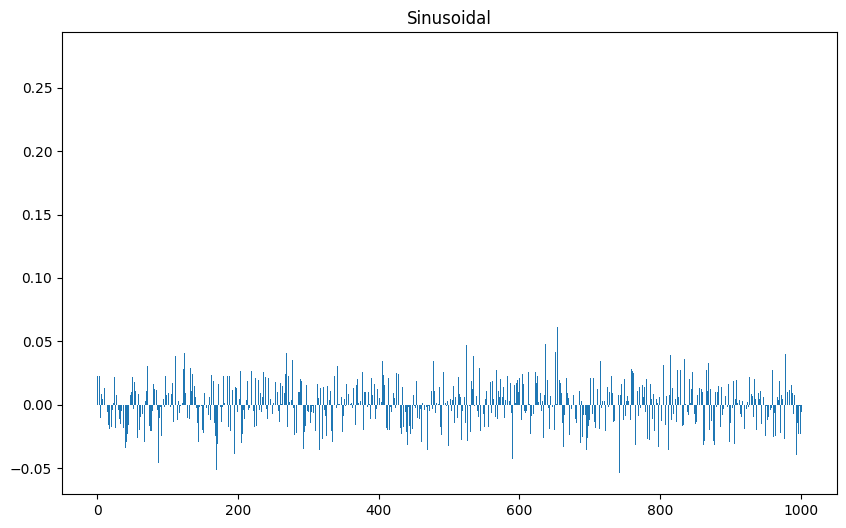

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

# Parameters
train_len = 3000
test_len = 1000
init_len = 1000
reservoir_size = 1000
spectral_radius = 0.8
reg = 1e-8

# Generate sinusoidal
def generate_sinusoidal(length):
    n = np.arange(1, length + 1)
    return 0.5 * np.sin(n / 4)

# Create dataset
data = generate_sinusoidal(train_len + test_len)

# Plot data
plt.figure()
plt.plot(data[:1000])
plt.title(" sinusoidal data")
plt.show()

# Generate ESN reservoir
np.random.seed(42)
Win = (np.random.rand(reservoir_size, 1 + 1) - 0.5) * 0.2  # Scale as per lab
W = np.random.rand(reservoir_size, reservoir_size) - 0.5
rhoW = max(abs(np.linalg.eigvals(W)))
W *= spectral_radius / rhoW

# Allocate memory for the design matrix
X = np.zeros((1 + 1 + reservoir_size, train_len - init_len))
Yt = data[None, init_len + 1 : train_len + 1]  # Target matrix

# Run the reservoir and collect states
x = np.zeros((reservoir_size, 1))
for t in range(train_len):
    u = data[t]
    x = np.tanh(np.dot(Win, np.vstack((1, u))) + np.dot(W, x))  # α=1 as per lab
    if t >= init_len:
        X[:, t - init_len] = np.vstack((1, u, x))[:, 0]

# Train ESN using ridge regression
Wout = solve(np.dot(X, X.T) + reg * np.eye(1 + 1 + reservoir_size), np.dot(X, Yt.T)).T

# Test ESN in generative mode
Y = np.zeros((1, test_len))
u = data[train_len]
for t in range(test_len):
    x = np.tanh(np.dot(Win, np.vstack((1, u))) + np.dot(W, x))
    y = np.dot(Wout, np.vstack((1, u, x)))
    Y[:, t] = y
    u = y  # Generative mode

# RMSE for 500 steps
error_len = 500
mse = np.mean((data[train_len + 1 : train_len + error_len + 1] - Y[0, :error_len]) ** 2)
rmse = np.sqrt(mse)
print(f"RMSE for first 500 steps = {rmse}")

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(data[train_len + 1 : train_len + test_len + 1], 'g', label="Target signal")
plt.plot(Y.T, 'b', label="Predicted signal")
plt.title("Target vs Predicted Signal (Sinusoidal)")
plt.xlabel("Time Steps")
plt.ylabel("Signal Value")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(X[0:20, 0:200].T)
plt.title("Activations sinusoidal")
plt.show()

plt.figure(figsize=(10, 6))
plt.bar(np.arange(1 + 1 + reservoir_size), Wout[0].T)
plt.title("Sinusoidal")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def load_swedish_leaf_dataset(filepath):
    X_list, y_list = [], []
    with open(filepath, 'r') as f:
        for line in f:
            line_data = line.strip().split('\t')
            class_label = int(float(line_data[0]))
            series = np.array(line_data[1:], dtype=float)
            X_list.append(series)
            y_list.append(class_label)
    return X_list, y_list

def normalize_signals(signal_list, mean, std):
    return [(signal - mean) / std for signal in signal_list]

def one_hot_encode(labels, num_classes):
    oh = np.zeros((len(labels), num_classes), dtype=float)
    for i in range(len(labels)):
        label = labels[i]
        oh[i, label - 1] = 1.0
    return oh

def build_esn(input_dim, reservoir_size, spectral_radius, input_scale, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    Win = (2 * np.random.rand(reservoir_size, 1 + input_dim) - 1) * input_scale
    W = 2 * np.random.rand(reservoir_size, reservoir_size) - 1
    W *= spectral_radius / np.max(np.abs(np.linalg.eigvals(W)))
    return Win, W

def train_esn(X_train, Y_train_1hot, Win, W, leaking_rate, reg):
    reservoir_size = W.shape[0]
    X_design = np.zeros((reservoir_size, len(X_train)))

    for i in range(len(X_train)):
        signal = X_train[i]
        x = np.zeros((reservoir_size, 1))  # Initialize reservoir state
        for t in signal:  # Process time steps
            input_vector = np.vstack((1.0, t))
            x = (1 - leaking_rate) * x + leaking_rate * np.tanh(np.dot(Win, input_vector) + np.dot(W, x))
        X_design[:, i] = x[:, 0]

    # Ridge regression to compute Wout
    Wout = np.dot(np.dot(Y_train_1hot.T, X_design.T), np.linalg.inv(
        np.dot(X_design, X_design.T) + reg * np.eye(reservoir_size)
    ))
    return Wout

def test_esn(X_test, y_test, Win, W, Wout, leaking_rate):
    correct = 0
    for i in range(len(X_test)):
        signal = X_test[i]
        x = np.zeros((W.shape[0], 1))
        for t in signal:
            input_vector = np.vstack((1.0, t))
            x = (1 - leaking_rate) * x + leaking_rate * np.tanh(np.dot(Win, input_vector) + np.dot(W, x))
        output = np.dot(Wout, x)
        if np.argmax(output) + 1 == y_test[i]:
            correct += 1
    return correct / len(X_test)

reservoir_size = 800
spectral_radius = 0.99
input_scale = 0.25
leaking_rate = 0.3
reg = 1e-6
num_runs = 10

train_file_path = 'SwedishLeaf_TRAIN.tsv'
test_file_path = 'SwedishLeaf_TEST.tsv'
X_train, y_train = load_swedish_leaf_dataset(train_file_path)
X_test, y_test = load_swedish_leaf_dataset(test_file_path)

mean = np.mean([value for signal in X_train for value in signal])
std = np.std([value for signal in X_train for value in signal])
X_train = normalize_signals(X_train, mean, std)
X_test = normalize_signals(X_test, mean, std)

num_classes = len(set(y_train + y_test))
Y_train_1hot = one_hot_encode(y_train, num_classes)

accuracies = []
for run_idx in range(num_runs):
    Win, W = build_esn(1, reservoir_size, spectral_radius, input_scale, random_state=42 + run_idx)
    Wout = train_esn(X_train, Y_train_1hot, Win, W, leaking_rate, reg)
    acc = test_esn(X_test, y_test, Win, W, Wout, leaking_rate)
    accuracies.append(acc)
    print(f"Run {run_idx + 1}: Accuracy = {acc}")

avg_accuracy = np.mean(accuracies)
print(f"\nAverage accuracy: {avg_accuracy}")


Run 1: Accuracy = 0.8192
Run 2: Accuracy = 0.8416
Run 3: Accuracy = 0.84
Run 4: Accuracy = 0.8448
Run 5: Accuracy = 0.8464
Run 6: Accuracy = 0.8496
Run 7: Accuracy = 0.8432
Run 8: Accuracy = 0.8432
Run 9: Accuracy = 0.816
Run 10: Accuracy = 0.8272

Average accuracy: 0.83712
